In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import yfinance as yf
import statsmodels.tsa.api as sm
import matplotlib.dates as mdates
import scipy.stats as stats
import statsmodels.graphics.tsaplots as sgt



In [181]:
FCHI = yf.Ticker("^FCHI")
start_date = dt.datetime(2013, 2,1)
end_date = dt.datetime(2025, 3, 11)
FCHI_df = FCHI.history(start=start_date, end=end_date, auto_adjust=False)

In [208]:
FCHI_df['Log Returns'] = np.log(FCHI_df['Adj Close'] / FCHI_df['Adj Close'].shift(1)) * 100
FCHI_df['Squared Returns'] = FCHI_df['Log Returns'] ** 2
FCHI_df.loc[:,['Log Returns', 'Squared Returns']].head()

,Log Returns,Squared Returns
Date,,
2013-02-01 00:00:00+01:00,NaN,NaN
2013-02-04 00:00:00+01:00,-3.057238,9.346703
2013-02-05 00:00:00+01:00,0.946081,0.895070
2013-02-06 00:00:00+01:00,-1.411931,1.993548
2013-02-07 00:00:00+01:00,-1.155456,1.335078


In [183]:
fig, axs = plt.subplots(3,1, figsize=(24, 15), sharex=True, dpi=500)
FCHI_df['Adj Close'].plot(ax=axs[0], title='CAC 40 Index Adj Closing Price', color='blue')
FCHI_df['Log Returns'].plot(ax=axs[1], title='CAC 40 Index Log Returns', color='red')
FCHI_df['Squared Returns'].plot(ax=axs[2], title='CAC 40 Index Squared Returns', color='green')

axs[0].xaxis.set_major_locator(mdates.YearLocator())
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.title.set_size(18)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

plt.legend()
plt.tight_layout()

In [212]:
def summary_statistic(series):
    mean = series.mean() 
    std = series.std(ddof=1) 
    skew = series.skew()
    kurt = series.kurtosis()
    summary = pd.DataFrame([mean, std, skew, kurt], index=['Mean (%)', 'Std (%)', 'Skew', 'Kurt'], columns=['Value'])
    return summary

summary = summary_statistic(FCHI_df['Log Returns'].dropna())
summary

,Value
Mean (%),0.024471
Std (%),1.156503
Skew,-0.794630
Kurt,10.627747


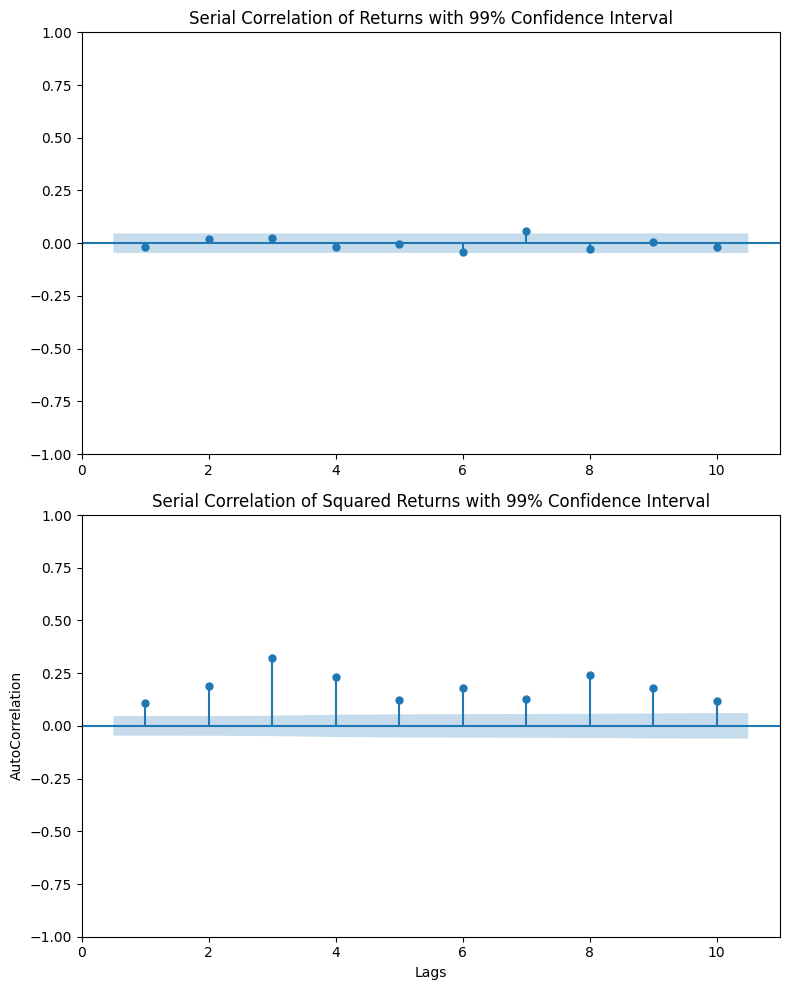

In [214]:
fig, axs = plt.subplots(2,1, figsize =(8,10), sharex = False, sharey = True)
FCHI_acf = sm.acf(FCHI_df['Log Returns'].dropna(), nlags=10)
plot_acf_returns = sgt.plot_acf(FCHI_df['Log Returns'].dropna(), ax=axs[0], lags=10, alpha = 0.01, title='Serial Correlation of Returns with 99% Confidence Interval', zero=False)
plot_acf_squared_returns = sgt.plot_acf(FCHI_df['Squared Returns'].dropna(), lags=10, ax=axs[1], alpha = 0.01, title='Serial Correlation of Squared Returns with 99% Confidence Interval', zero=False)
plt.xlabel('Lags')
plt.ylabel('AutoCorrelation')
plt.tight_layout()


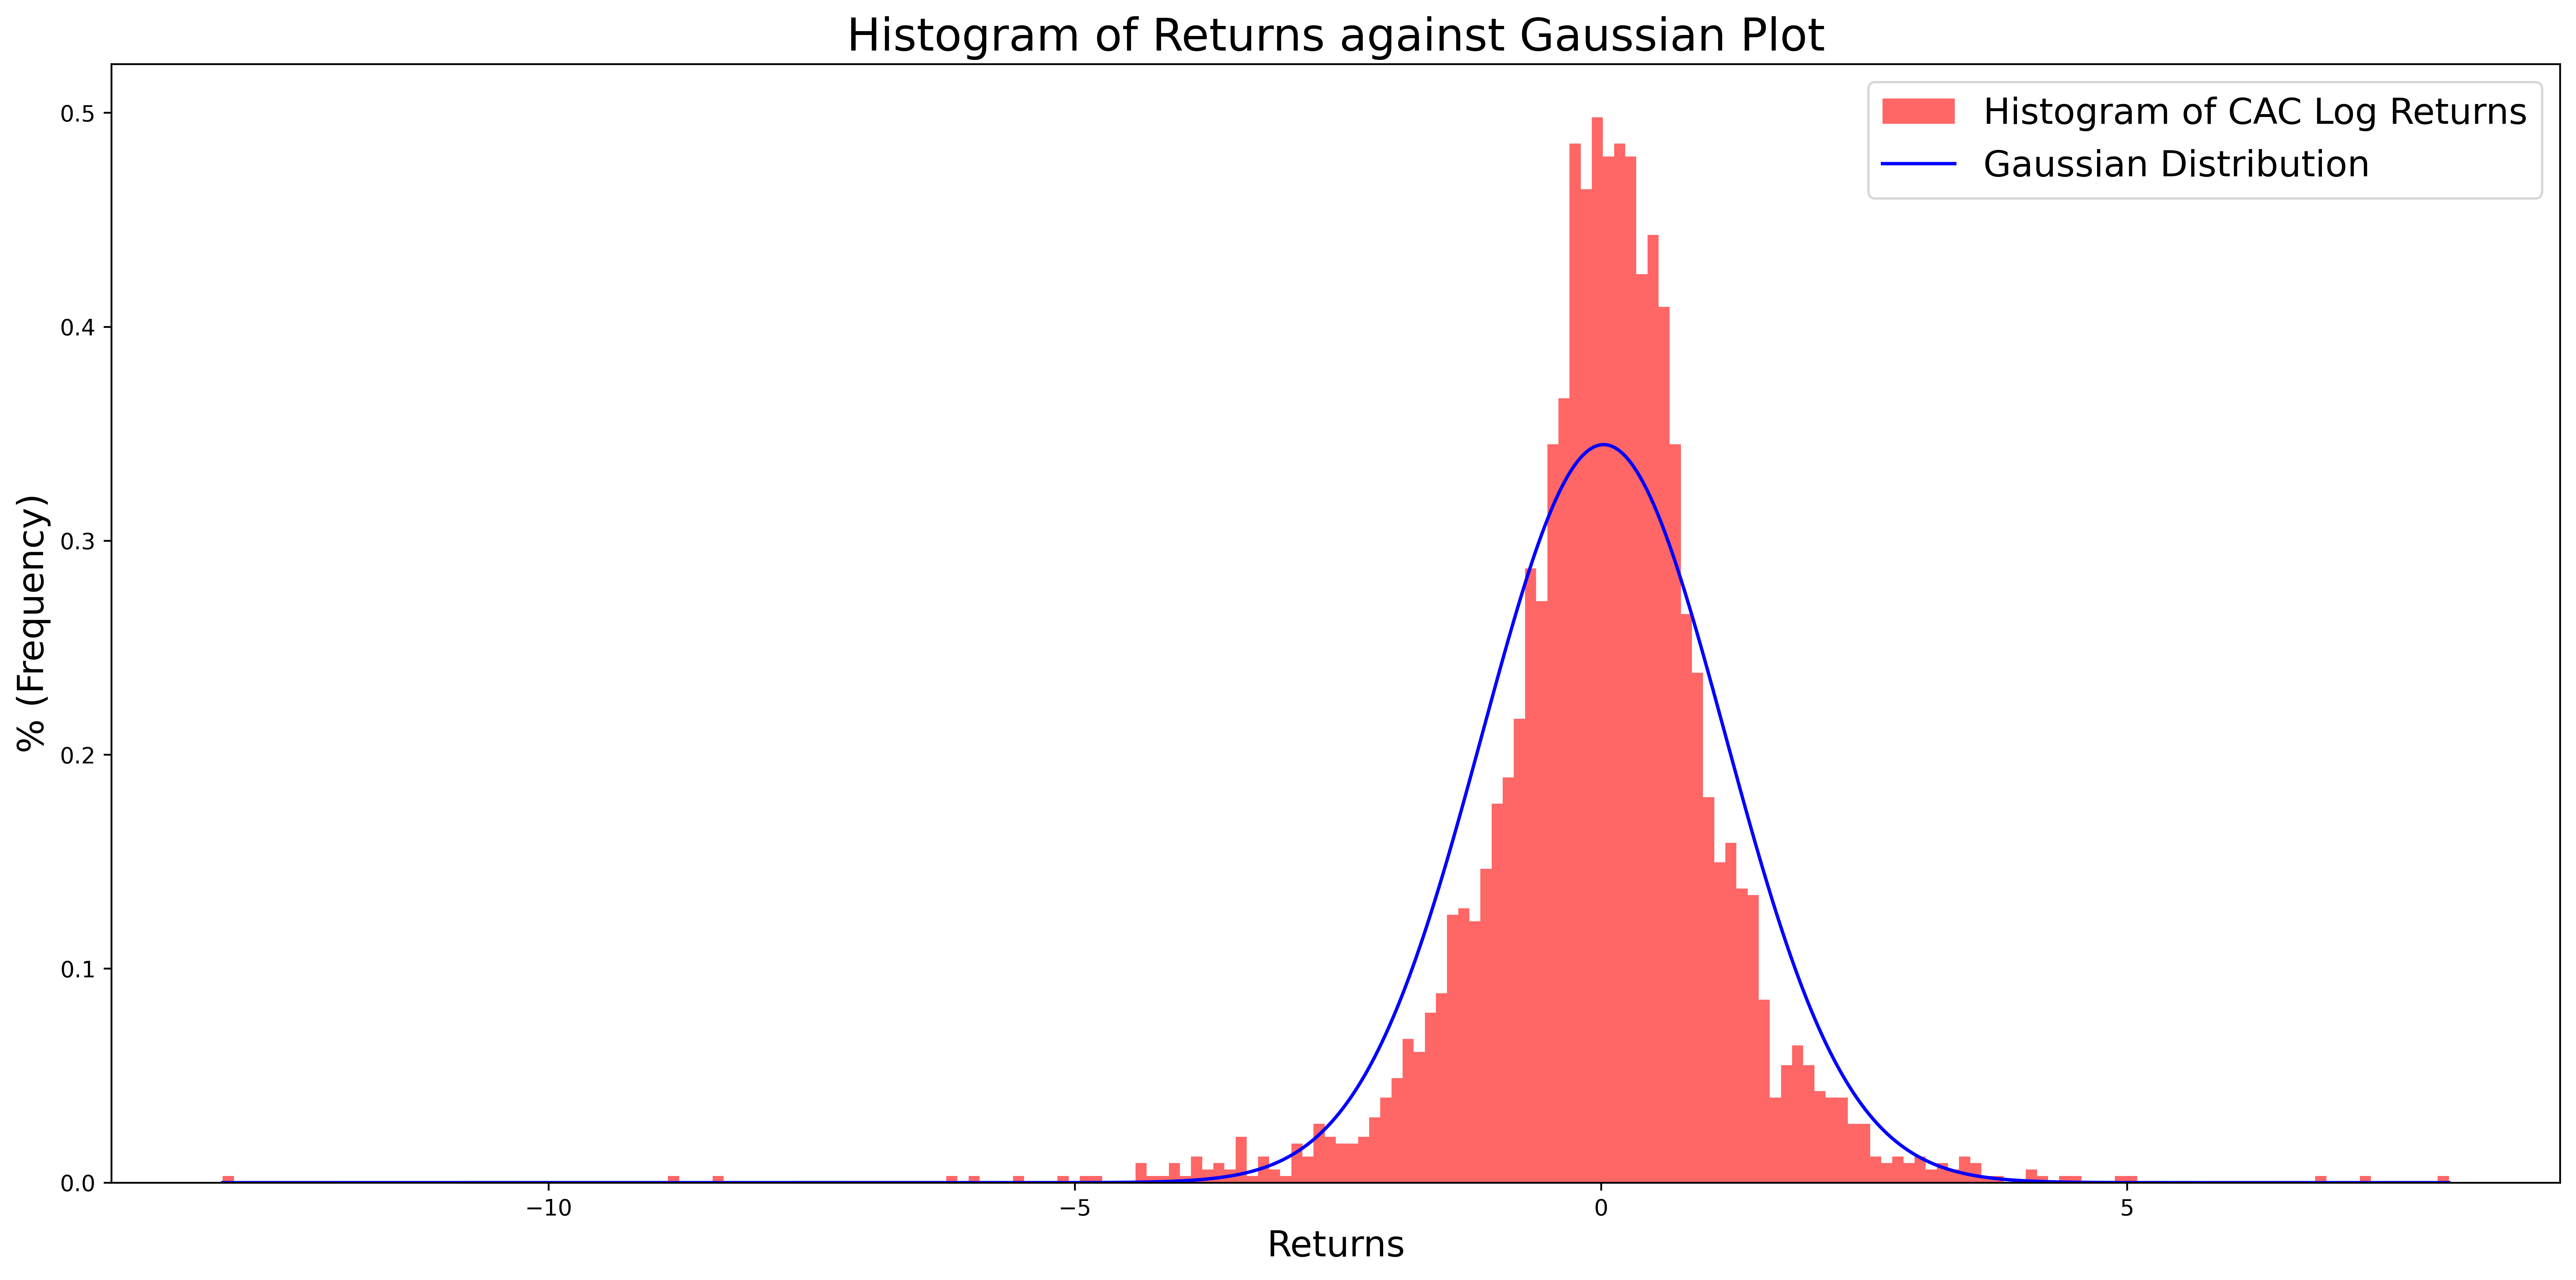

In [215]:
#Setting up Plot
fig, axs = plt.subplots(1, figsize=(16,8), label='Log Returns of CAC', dpi = 500)

#Histogram 
axs.hist(FCHI_df['Log Returns'], bins = 200, color='red', alpha = 0.6, label='Histogram of CAC Log Returns', density = True)

#Gaussian
mean = summary.loc['Mean (%)']['Value']
std = summary.loc['Std (%)']['Value']
x = np.linspace(FCHI_df['Log Returns'].min(), FCHI_df['Log Returns'].max(), len(FCHI_df['Log Returns']))
axs.plot(x, stats.norm.pdf(x, mean, std), color='blue', label='Gaussian Distribution')

#Labels 
plt.title('Histogram of Returns against Gaussian Plot', fontsize=20)
plt.xlabel('Returns', fontsize = 16)
plt.ylabel('% (Frequency)', fontsize = 16)
plt.legend(fontsize=16)
plt.tight_layout()


## Question 2

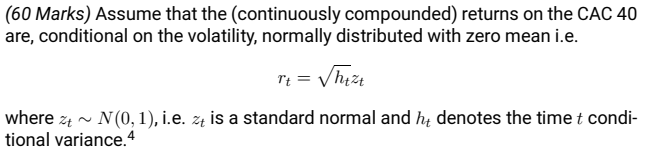

### Moving Average Model

In [187]:
from statsmodels.tsa.arima.model import ARIMA

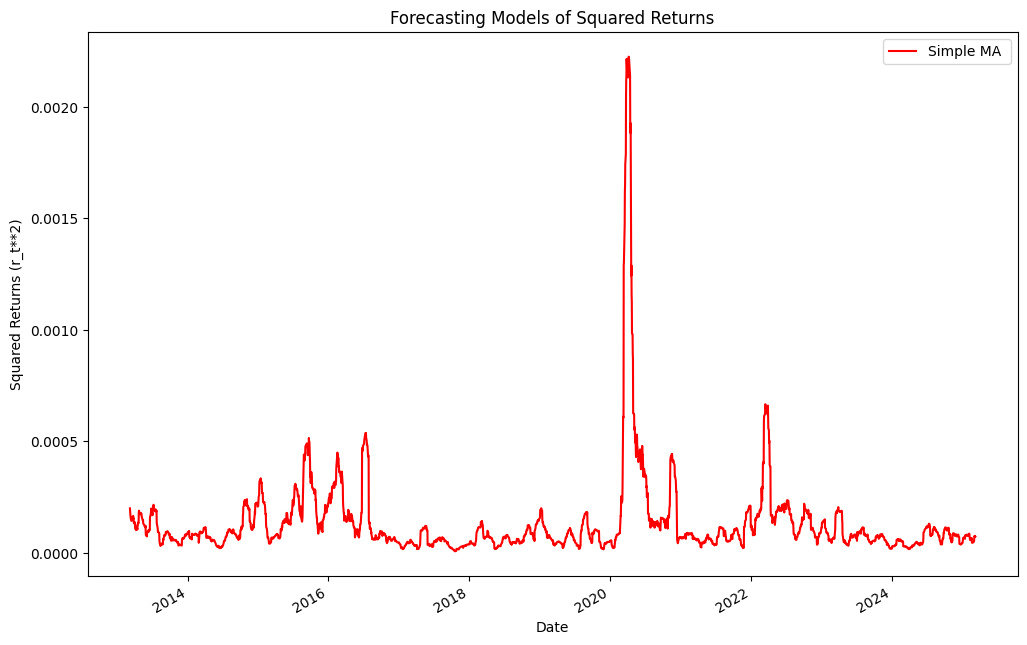

In [310]:
#Simple MA
FCHI_df['Simple MA(25)'] = FCHI_df['Squared Returns'].rolling(window=25).mean() / 10000
#Divide by 100
SMA_Result = FCHI_df['Simple MA(25)'].dropna() 
SMA_Result.plot(label = 'Simple MA ', color = 'red', figsize=(12,8))
plt.title('Forecasting Models of Squared Returns')
plt.ylabel('Squared Returns (r_t**2)')
plt.xlabel('Date')
plt.legend()

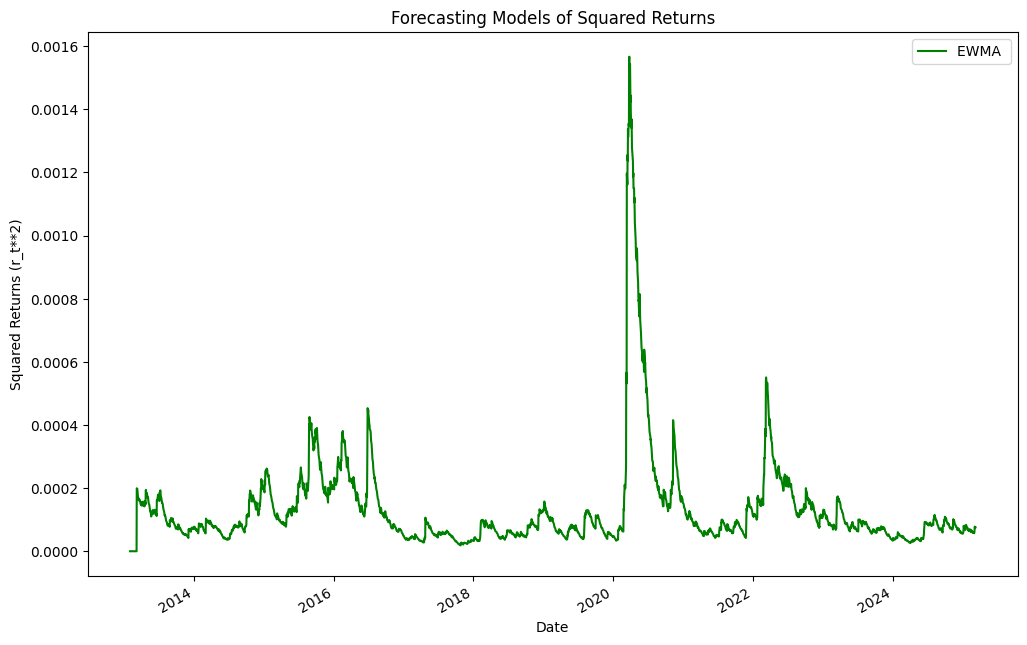

In [305]:
#EWMA - can use Pandas .ewm() if we don't want to set initial value
decay = 0.96
N = 25

#Initialise array to store EWMA 
h_t = np.zeros(len(FCHI_df['Log Returns']))
h_t[N] = FCHI_df['Simple MA(25)'].dropna().iloc[0]  / 100

#Apply EWMA formula from t = N + 1 (26)
for timestep in range(N+1, len(FCHI_df['Log Returns'])):
    h_t[timestep] = (1 - decay) * (FCHI_df['Squared Returns'].iloc[timestep - 1]) / 10000 + (decay) * h_t[timestep -1] 

FCHI_df['EWMA'] = h_t

#EWM Plot
FCHI_df['EWMA'].plot(label = 'EWMA ', color = 'green', figsize=(12,8))
plt.title('Forecasting Models of Squared Returns')
plt.ylabel('Squared Returns (r_t**2)')
plt.xlabel('Date')
plt.legend()


In [308]:
#Garch Parameters
w = 3.407e-06 
alpha = 1.078e-01
beta = 0.8719
initial_h = 0.000172836

#GARCH Model
garch_ht = np.zeros(len(FCHI_df['Log Returns']))
garch_ht[0] = initial_h 

for i in range(1, len(garch_ht)):
    garch_ht[i] = w + alpha * FCHI_df['Squared Returns'].iloc[i] / 10000 + beta * garch_ht[i-1]

FCHI_df['GARCH Forecast'] = garch_ht 

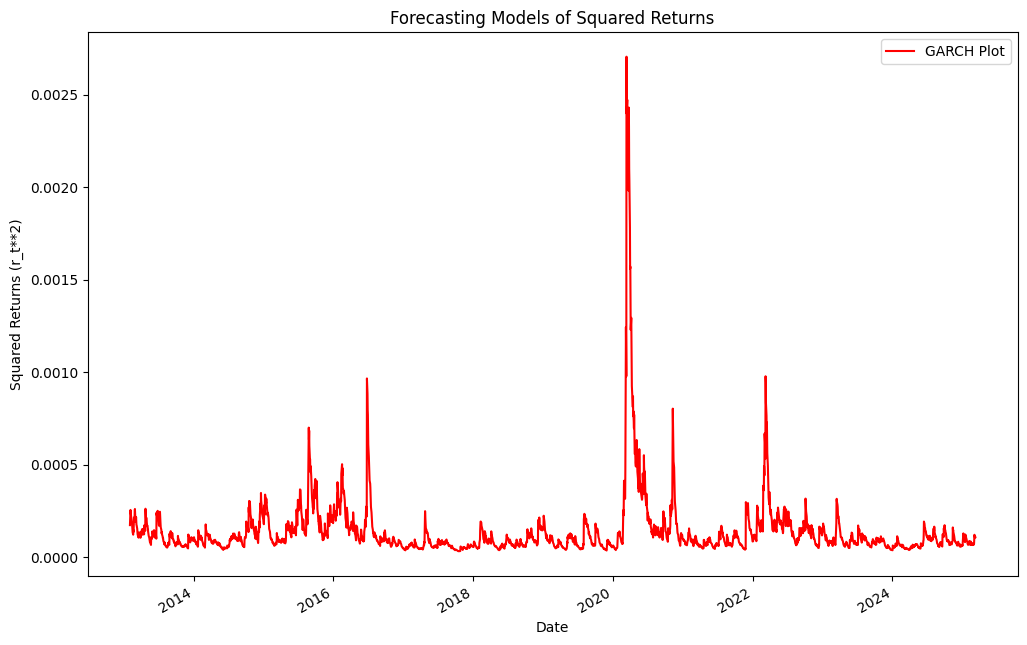

In [309]:
#Plot
FCHI_df['GARCH Forecast'].plot(label = 'GARCH Plot', color = 'red', figsize=(12,8))
plt.title('Forecasting Models of Squared Returns')
plt.ylabel('Squared Returns (r_t**2)')
plt.xlabel('Date')
plt.legend()


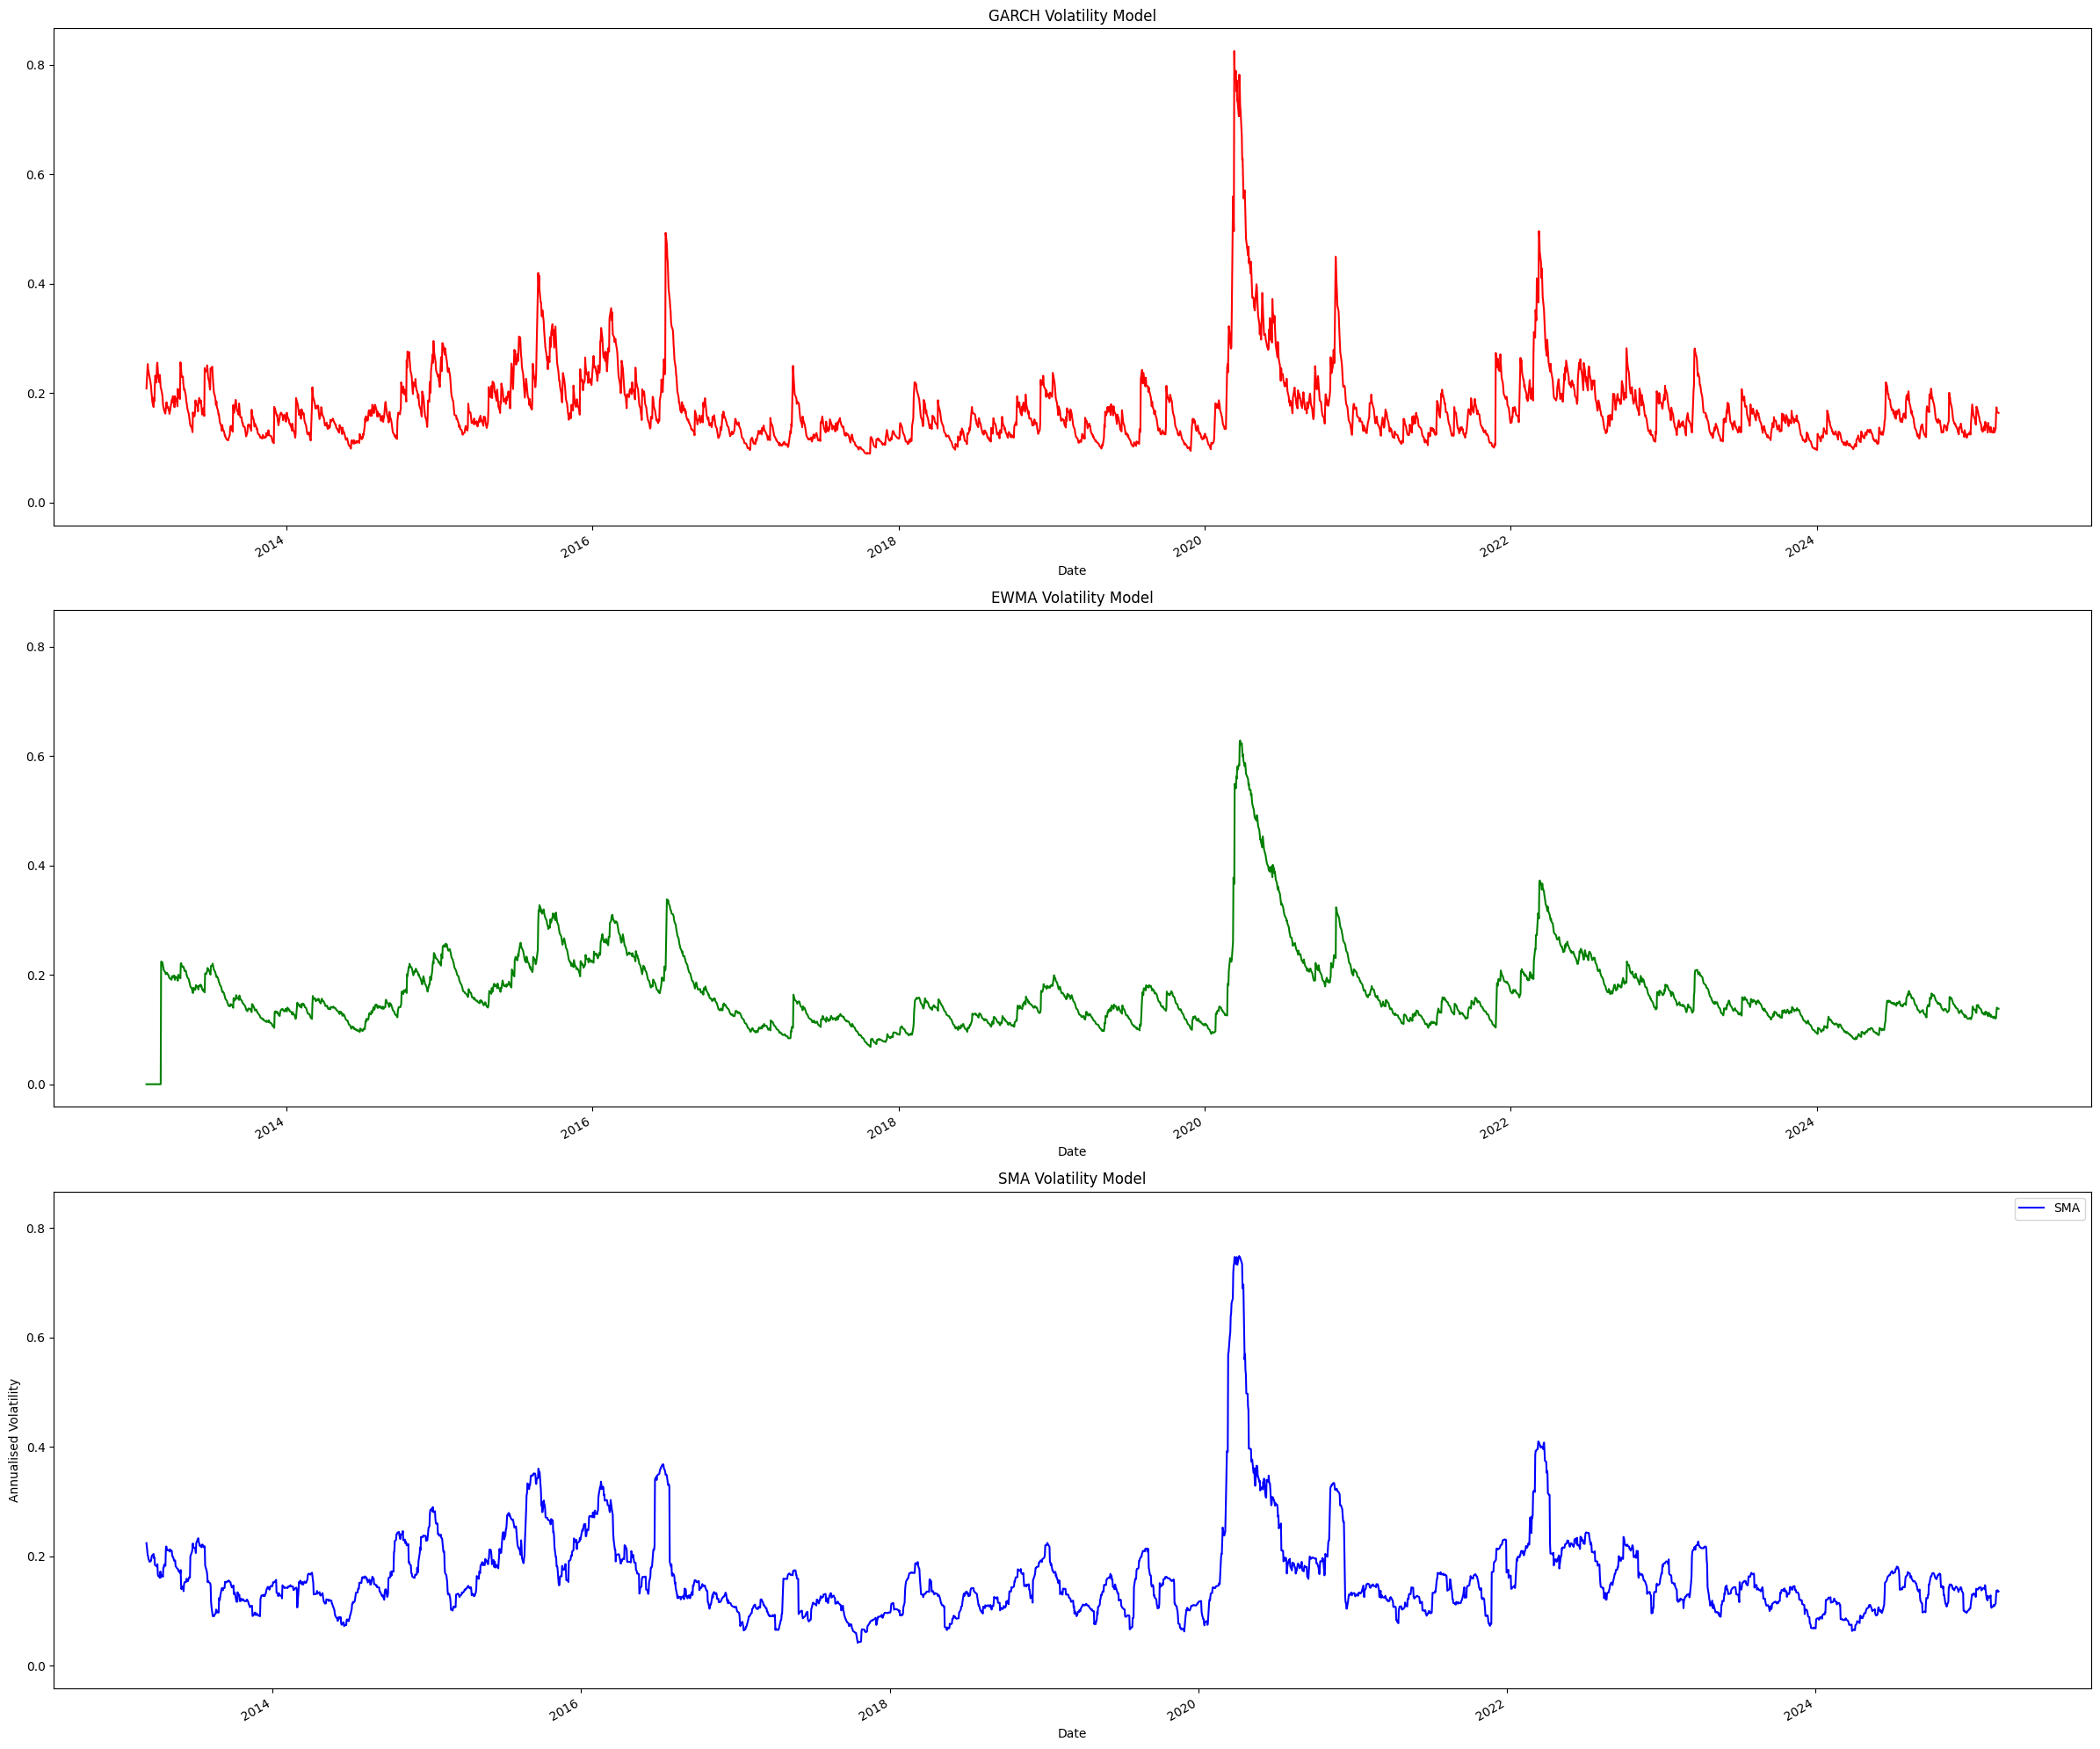

In [311]:
#Turn Variance into Volatility
Volatility_Forecast_df = np.sqrt(FCHI_df.loc[:, ['GARCH Forecast', 'EWMA', 'Simple MA(25)']]) * np.sqrt(252)
#Plot Volatility 
fig, axs = plt.subplots(3,1, figsize=(24, 20), sharey= True, label='Volatility Forecast')
plt.title('Annualised Conditional Volatility Estimates')
Volatility_Forecast_df['GARCH Forecast'].plot(ax=axs[0], label = 'GARCH', color='red', title = 'GARCH Volatility Model')
Volatility_Forecast_df['EWMA'].plot(ax=axs[1], label = 'EWMA', color='green', title = 'EWMA Volatility Model')
Volatility_Forecast_df['Simple MA(25)'].plot(ax=axs[2], label = 'SMA', color='blue', title = 'SMA Volatility Model')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Annualised Volatility')
plt.tight_layout()


In [313]:
Volatility_Forecast_df.dropna().corr()

,GARCH Forecast,EWMA,Simple MA(25)
GARCH Forecast,1.000000,0.876878,0.912337
EWMA,0.876878,1.000000,0.942529
Simple MA(25),0.912337,0.942529,1.000000


## VAR

In [464]:
returns = FCHI_df['Log Returns'] / 100
GARCH_Volatility = Volatility_Forecast_df['GARCH Forecast']
EWMA_Volatility = Volatility_Forecast_df['EWMA']
MA_Volatility = Volatility_Forecast_df['Simple MA(25)']

In [ ]:
def daily_VaR(ax, volatility, title, returns = returns, alpha = 0.05):

    VaR_Daily = pd.Series(stats.norm.ppf(alpha, scale=volatility) / np.sqrt(252))
    VaR_Daily.index = returns.index
    returns.plot(ax = ax)
    VaR_Daily.plot(ax = ax, title=title)

    return VaR_Daily



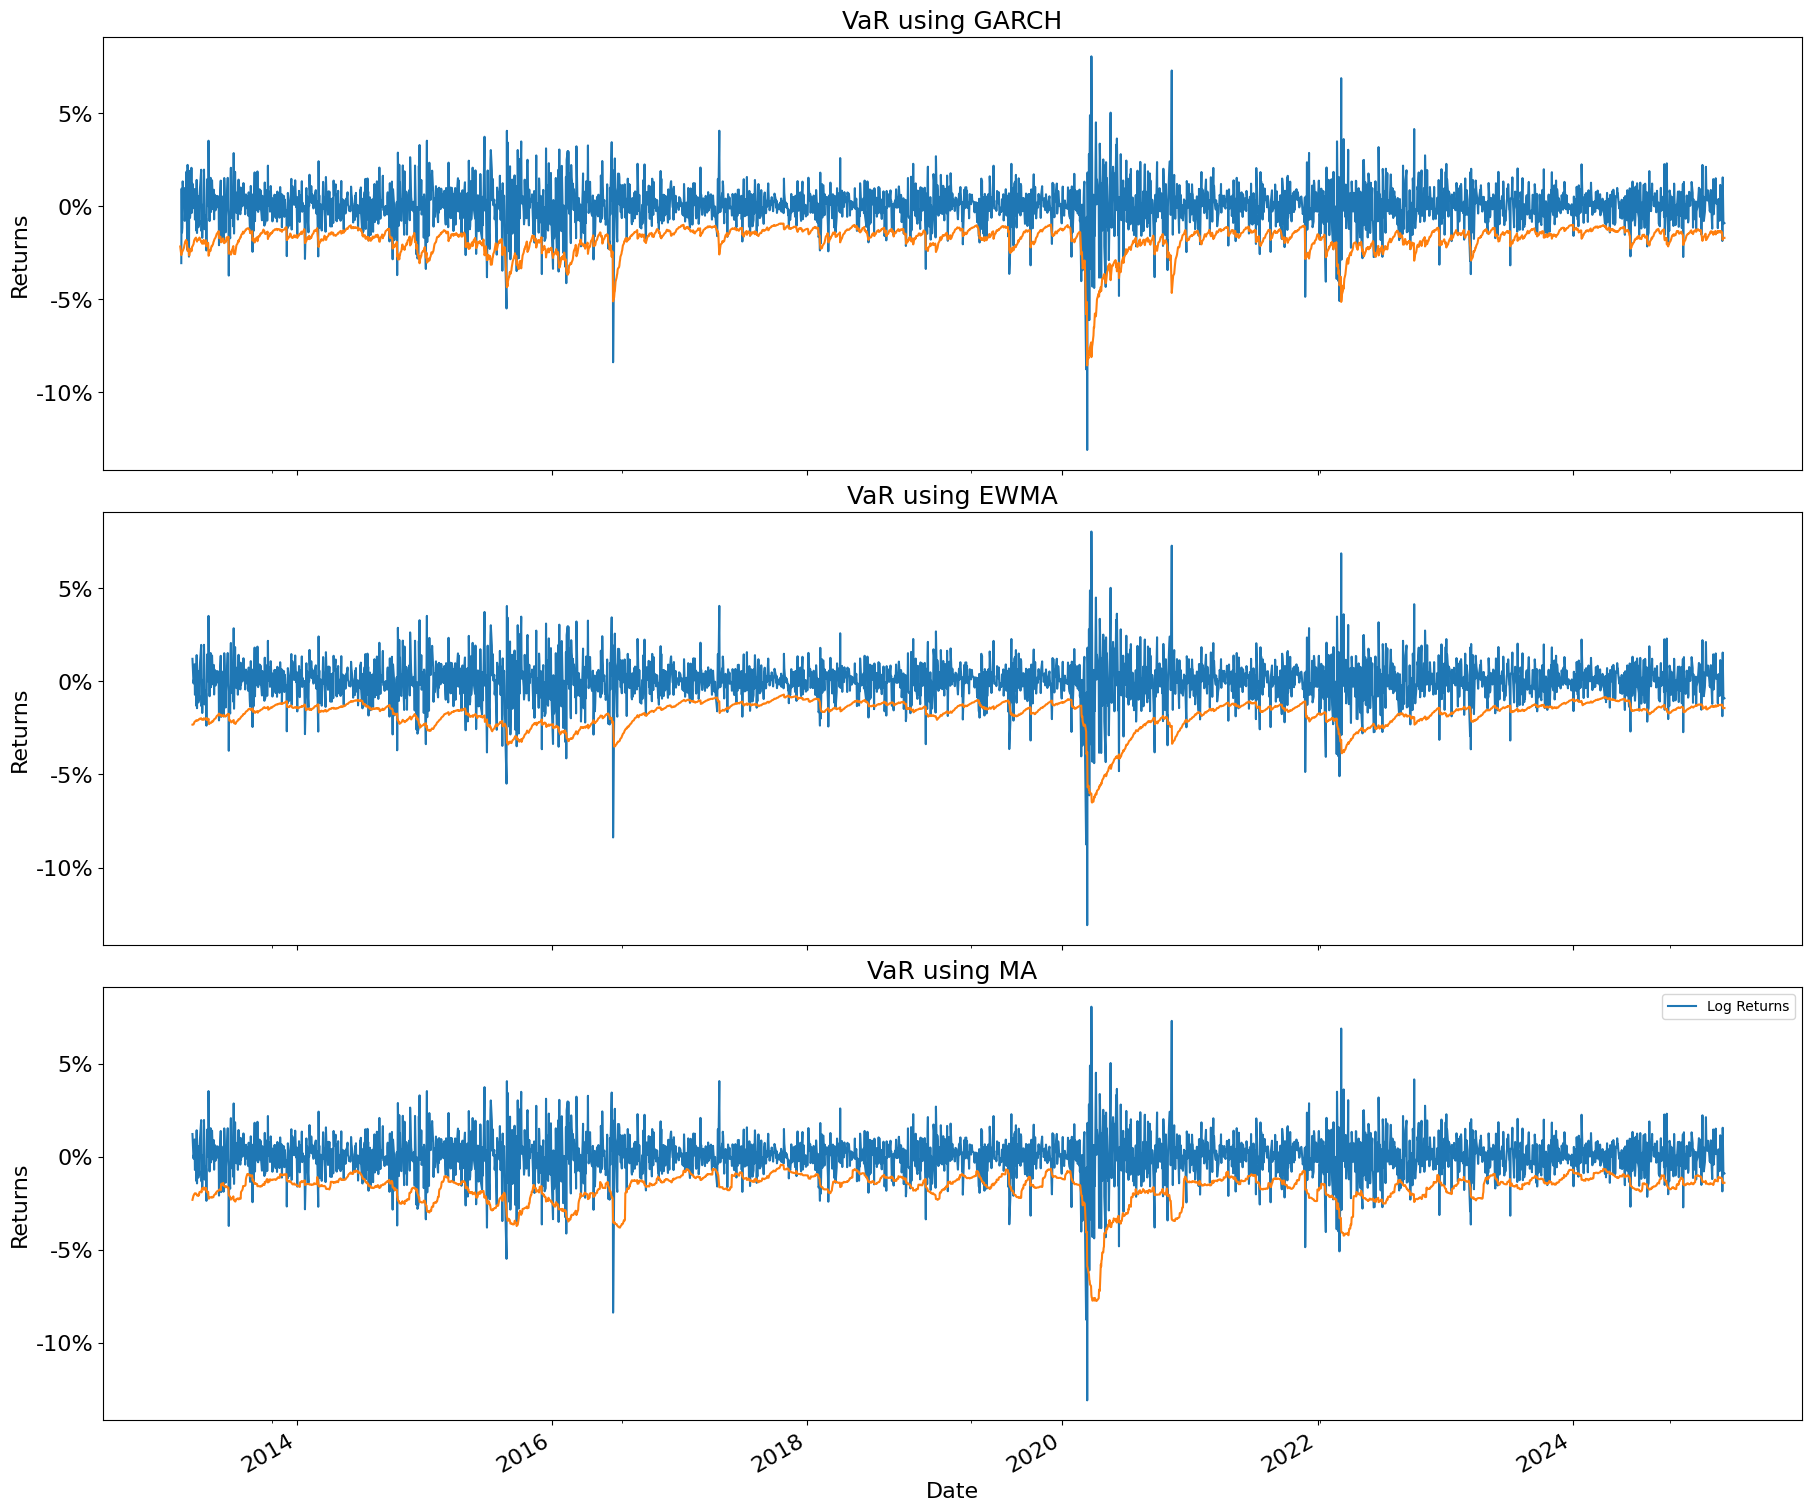

In [522]:
#Plotting 
fig, axs = plt.subplots(3,1, figsize=(18, 15), layout='constrained', sharex=True)
ax1, ax2, ax3 = axs.ravel()
VaR_Garch = daily_VaR(ax1, GARCH_Volatility, title= 'VaR using GARCH')
VaR_EWMA = daily_VaR(ax2, EWMA_Volatility[25:], returns = returns[25:], title= 'VaR using EWMA')
VaR_MA = daily_VaR(ax3, MA_Volatility[25:], returns = returns[25:], title = 'VaR using MA')

for ax in axs:
    ax.set_ylabel('Returns')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.title.set_size(18)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.set_yticks([-0.10, -0.05, 0,0.05], ['-10%', '-5%', '0%', '5%'])

plt.legend()

,0,1,2,3,4,5,6,7,8,9,...,3086,3087,3088,3089,3090,3091,3092,3093,3094,3095
0,0.40904,0.496706,0.477233,0.471888,0.459765,0.454140,0.427937,0.415955,0.394013,0.380910,...,0.250609,0.267916,0.261902,0.251467,0.265717,0.318266,0.341662,0.325528,0.323967,0.321503
1,NaN,-0.030572,0.009461,-0.014119,-0.011555,0.013365,0.000296,0.009813,0.003236,-0.007853,...,-0.004946,0.011467,-0.005097,0.001124,0.010800,-0.018685,0.015514,0.002922,-0.009421,-0.009055


In [429]:
returns

Date
2013-02-01 00:00:00+01:00         NaN
2013-02-04 00:00:00+01:00   -0.030572
2013-02-05 00:00:00+01:00    0.009461
2013-02-06 00:00:00+01:00   -0.014119
2013-02-07 00:00:00+01:00   -0.011555
                               ...   
2025-03-04 00:00:00+01:00   -0.018685
2025-03-05 00:00:00+01:00    0.015514
2025-03-06 00:00:00+01:00    0.002922
2025-03-07 00:00:00+01:00   -0.009421
2025-03-10 00:00:00+01:00   -0.009055
Name: Log Returns, Length: 3096, dtype: float64